# Notebook 02 — feature Engineering

## Imports

In [111]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

import gc
pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (12, 6)

In [25]:
# --- helpers ---

def info_rapide(df, name="df"):
    """
    Affiche un aperçu global rapide d’un DataFrame :
    - Dimensions (nombre de lignes/colonnes)
    - 3 premières et 3 dernières lignes pour voir la structure
    - Statistiques descriptives sur toutes les colonnes (quanti + quali)
    """
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print(df.info())
    display(df.head(3))
    display(df.tail(3))
    display(df.describe(include="all"))

In [26]:
# List files available
print(os.listdir("../data/raw"))

['application_test.csv', '.DS_Store', 'HomeCredit_columns_description.csv', 'POS_CASH_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'application_train.csv', 'bureau.csv', 'previous_application.csv', 'bureau_balance.csv', 'sample_submission.csv']


In [27]:
#Chargement des fichiers
application_test = pd.read_csv("../data/raw/application_test.csv")
application_train = pd.read_csv("../data/raw/application_train.csv")
bureau = pd.read_csv("../data/raw/bureau.csv")
bureau_balance = pd.read_csv("../data/raw/bureau_balance.csv")
POS_CASH_balance = pd.read_csv("../data/raw/POS_CASH_balance.csv")
credit_card_balance = pd.read_csv("../data/raw/credit_card_balance.csv")
previous_application = pd.read_csv("../data/raw/previous_application.csv")
installments_payments = pd.read_csv("../data/raw/installments_payments.csv")
HomeCredit_columns_description = pd.read_csv("../data/raw/HomeCredit_columns_description.csv", encoding="latin1")

sample_submission = pd.read_csv("../data/raw/sample_submission.csv")

In [28]:
datasets = {
    "application_train": application_train,
    "application_test": application_test,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_application,
    "POS_CASH_balance": POS_CASH_balance,
    "installments_payments": installments_payments,
    "credit_card_balance": credit_card_balance
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

application_train: (307511, 122)
application_test: (48744, 121)
bureau: (1716428, 17)
bureau_balance: (27299925, 3)
previous_application: (1670214, 37)
POS_CASH_balance: (10001358, 8)
installments_payments: (13605401, 8)
credit_card_balance: (3840312, 23)


In [29]:
info_rapide(application_test, "TEST")
info_rapide(application_train, "TRAIN")
info_rapide(bureau, "BUREAU")
info_rapide(bureau_balance, "bureau_balance")
info_rapide(POS_CASH_balance, "POS_CASH_balance")
info_rapide(credit_card_balance, "credit_card_balance")
info_rapide(previous_application, "previous_application")
info_rapide(installments_payments, "installments_payments")
info_rapide(HomeCredit_columns_description, "HomeCredit_columns_description")
info_rapide(sample_submission, "sample_submission")


=== TEST ===
shape: (48744, 121)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 121 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), object(16)
memory usage: 45.0+ MB
None


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.066,0.059,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.059,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.026392,-15922,-3037,-2681.0,-1504,4.0,1,1,0,1,1,0,NaN,3.0,2,2,WEDNESDAY,12,0,0,0,0,0,0,Business Entity Type 3,0.733503,0.632770,0.283712,0.1113,0.1364,0.9955,NaN,NaN,0.16,0.1379,0.3333,NaN,NaN,NaN,0.1383,NaN,0.0542,0.1134,0.1415,0.9955,NaN,NaN,0.1611,0.1379,0.3333,NaN,NaN,NaN,0.1441,NaN,0.0574,0.1124,0.1364,0.9955,NaN,NaN,0.16,0.1379,0.3333,NaN,NaN,NaN,0.1408,NaN,0.0554,NaN,block of flats,0.1663,"Stone, brick",No,0.0,0.0,0.0,0.0,-838.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,3.0,1.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,Family,Commercial associate,Higher education,Married,House / apartment,0.018850,-13968,-2731,-1461.0,-1364,NaN,1,1,1,1,1,0,Managers,2.0,2,2,MONDAY,10,0,1,1,0,1,1,Self-employed,0.373090,0.445701,0.595456,0.1629,0.0723,0.9896,NaN,NaN,0.16,0.0690,0.6250,NaN,NaN,NaN,0.1563,NaN,0.1490,0.1660,0.0750,0.9896,NaN,NaN,0.1611,0.0690,0.6250,NaN,NaN,NaN,0.1204,NaN,0.1577,0.1645,0.0723,0.9896,NaN,NaN,0.16,0.0690,0.6250,NaN,NaN,NaN,0.1591,NaN,0.1521,NaN,block of flats,0.1974,Panel,No,0.0,0.0,0.0,0.0,-2308.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
48743,456250,Cash loans,F,Y,N,0,135000.0,312768.0,24709.5,270000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.006629,-13962,-633,-1072.0,-4220,22.0,1,1,1,1,0,0,Core staff,2.0,2,2,TUESDAY,14,0,0,0,0,0,0,Government,NaN,0.456541,0.272134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-327.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,48744.000000,48744,48744,48744,48744,48744.000000,4.874400e+04,4.874400e+04,48720.000000,4.874400e+04,47833,48744,48744,48744,48744,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,16432.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,33139,48744.000000,48744.000000,48744.000000,48744,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744,28212.000000,48736.000000,40076.000000,24857.000000,21103.000000,25888.000000,16926.000000,15249.000000,23555.000000,25165.000000,25423.000000,16278.000000,20490.000000,15964.000000,25192.000000,15397.000000,22660.000000,24857.000000,21103.000000,25888.000000,16926.000000,15249.000000,23555.000000,25165.000000,25423.000000,16278.000000,20490.000000,15964.000000,25192.000000,15397.000000,22660.000000,24857.000000,21103.000000,25888.000000,16926.000000,15249.000000,23555.000000,25165.000000,25423.000000,16278.000000,20490.000000,15964.000000,25192.000000,15397.000000,22660.000000,15947,25125,26120.000000,24851,26535,48715.000000,48715.000000,48715.000000,48715.000000,48744.000000,48744.0,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.0,48744.000000,48744.0,48744.0,48744.0,48744.0,48744.0,48744.0,48744.000000,48744.0,48744.0,48744.0,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000
unique,NaN,2,2,2,2,NaN,NaN,NaN,NaN,NaN,7,7,5,5,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18,NaN,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3,NaN,7,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,


=== TRAIN ===
shape: (307511, 122)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None


...

,Unnamed: 0,Table,Row,Description,Special
count,219.000000,219,219,219,86
unique,NaN,7,196,163,7
top,NaN,application_{train|test}.csv,SK_ID_CURR,Normalized information about building where th...,normalized
freq,NaN,122,6,47,53
mean,111.981735,NaN,NaN,NaN,NaN
std,63.395726,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,57.500000,NaN,NaN,NaN,NaN
50%,112.000000,NaN,NaN,NaN,NaN
75%,166.500000,NaN,NaN,NaN,NaN



=== sample_submission ===
shape: (48744, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SK_ID_CURR  48744 non-null  int64  
 1   TARGET      48744 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 761.8 KB
None


,SK_ID_CURR,TARGET
0,100001,0.5
1,100005,0.5
2,100013,0.5


,SK_ID_CURR,TARGET
48741,456223,0.5
48742,456224,0.5
48743,456250,0.5


,SK_ID_CURR,TARGET
count,48744.000000,48744.0
mean,277796.676350,0.5
std,103169.547296,0.0
min,100001.000000,0.5
25%,188557.750000,0.5
50%,277549.000000,0.5
75%,367555.500000,0.5
max,456250.000000,0.5


In [89]:
RANDOM_STATE = 42
TARGET = "TARGET"
ID_CLIENT = "SK_ID_CURR"

## Fonctions utilitaires

In [92]:
def flatten_columns(df):
    """
    Aplatit les colonnes MultiIndex créées par un groupby().agg().
    """
    df = df.copy()

    df.columns = [
        "_".join(
            str(level)
            for level in column
            if str(level) not in ("", "None")
        ).upper()
        if isinstance(column, tuple)
        else str(column).upper()
        for column in df.columns
    ]

    return df


In [93]:
def safe_divide(numerator, denominator):
    """
    Réalise une division en remplaçant les dénominateurs nuls par NaN.
    """
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


In [94]:
def missing_values_report(df):
    """
    Crée un tableau de synthèse des valeurs manquantes.
    """
    missing_count = df.isna().sum()
    missing_rate = missing_count / len(df) * 100

    report = pd.DataFrame({
        "missing_count": missing_count,
        "missing_rate_pct": missing_rate
    })

    report = report.loc[report["missing_count"] > 0]
    report = report.sort_values(
        "missing_rate_pct",
        ascending=False
    )

    return report


In [95]:
def merge_client_features(base, features, table_name):
    """
    Fusionne une table agrégée avec la table principale tout en contrôlant
    les duplications et les pertes de lignes.
    """
    if ID_CLIENT not in features.columns:
        raise KeyError(
            f"{ID_CLIENT} absent de la table agrégée {table_name}"
        )

    if features[ID_CLIENT].duplicated().any():
        raise ValueError(
            f"{table_name} contient plusieurs lignes par client."
        )

    n_rows_before = len(base)
    n_clients_before = base[ID_CLIENT].nunique()

    result = base.merge(
        features,
        on=ID_CLIENT,
        how="left",
        validate="one_to_one"
    )

    assert len(result) == n_rows_before, (
        f"La fusion de {table_name} a modifié le nombre de lignes."
    )

    assert result[ID_CLIENT].nunique() == n_clients_before, (
        f"La fusion de {table_name} a modifié le nombre de clients."
    )

    print(
        f"{table_name}: fusion réussie — "
        f"{features.shape[1] - 1} variables ajoutées."
    )

    return result

## Contrôle clés de jointure

In [96]:
join_keys_report = pd.DataFrame({
    "table": [
        "application_train",
        "application_test",
        "bureau",
        "bureau_balance",
        "previous_application",
        "installments_payments",
        "POS_CASH_balance",
        "credit_card_balance"
    ],
    "client_key": [
        "SK_ID_CURR",
        "SK_ID_CURR",
        "SK_ID_CURR",
        None,
        "SK_ID_CURR",
        "SK_ID_CURR",
        "SK_ID_CURR",
        "SK_ID_CURR"
    ],
    "secondary_key": [
        None,
        None,
        "SK_ID_BUREAU",
        "SK_ID_BUREAU",
        "SK_ID_PREV",
        "SK_ID_PREV",
        "SK_ID_PREV",
        "SK_ID_PREV"
    ]
})

display(join_keys_report)

,table,client_key,secondary_key
0,application_train,SK_ID_CURR,None
1,application_test,SK_ID_CURR,None
2,bureau,SK_ID_CURR,SK_ID_BUREAU
3,bureau_balance,None,SK_ID_BUREAU
4,previous_application,SK_ID_CURR,SK_ID_PREV
5,installments_payments,SK_ID_CURR,SK_ID_PREV
6,POS_CASH_balance,SK_ID_CURR,SK_ID_PREV
7,credit_card_balance,SK_ID_CURR,SK_ID_PREV


## Nettoyer table principales

In [103]:
def clean_application(df):
    """
    Nettoie les anomalies connues de la table application.
    """
    df = df.copy()

    # Code genre très rare et ambigu
    if "CODE_GENDER" in df.columns:
        df["CODE_GENDER"] = df["CODE_GENDER"].replace(
            "XNA",
            np.nan
        )

    # Certaines colonnes contiennent également la modalité XNA
    object_columns = df.select_dtypes(
        include=["object", "category"]
    ).columns

    for column in object_columns:
        df[column] = df[column].replace(
            ["XNA", "Unknown"],
            np.nan
        )

    return df

In [101]:
application_train_clean = clean_application(
    application_train
)

application_test_clean = clean_application(
    application_test
)

## Créer des features métier dans la table principale

In [104]:
def create_application_features(df):
    """
    Crée des variables métier à partir de la demande de crédit actuelle.
    """
    df = df.copy()

    # Variables temporelles interprétables
    df["AGE_YEARS"] = (
        df["DAYS_BIRTH"].abs() / 365.25
    )

    df["EMPLOYED_YEARS"] = (
        df["DAYS_EMPLOYED"].abs() / 365.25
    )

    df["REGISTRATION_YEARS"] = (
        df["DAYS_REGISTRATION"].abs() / 365.25
    )

    df["ID_PUBLISH_YEARS"] = (
        df["DAYS_ID_PUBLISH"].abs() / 365.25
    )

    # Ratios financiers
    df["CREDIT_INCOME_RATIO"] = safe_divide(
        df["AMT_CREDIT"],
        df["AMT_INCOME_TOTAL"]
    )

    df["ANNUITY_INCOME_RATIO"] = safe_divide(
        df["AMT_ANNUITY"],
        df["AMT_INCOME_TOTAL"]
    )

    df["CREDIT_ANNUITY_RATIO"] = safe_divide(
        df["AMT_CREDIT"],
        df["AMT_ANNUITY"]
    )

    df["GOODS_CREDIT_RATIO"] = safe_divide(
        df["AMT_GOODS_PRICE"],
        df["AMT_CREDIT"]
    )

    df["INCOME_PER_PERSON"] = safe_divide(
        df["AMT_INCOME_TOTAL"],
        df["CNT_FAM_MEMBERS"]
    )

    df["ANNUITY_PER_PERSON"] = safe_divide(
        df["AMT_ANNUITY"],
        df["CNT_FAM_MEMBERS"]
    )

    # Ratios démographiques
    df["EMPLOYED_AGE_RATIO"] = safe_divide(
        df["DAYS_EMPLOYED"].abs(),
        df["DAYS_BIRTH"].abs()
    )

    df["CHILDREN_FAMILY_RATIO"] = safe_divide(
        df["CNT_CHILDREN"],
        df["CNT_FAM_MEMBERS"]
    )

    # Synthèse des scores externes
    external_sources = [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]

    df["EXT_SOURCE_MEAN"] = df[external_sources].mean(
        axis=1
    )

    df["EXT_SOURCE_MIN"] = df[external_sources].min(
        axis=1
    )

    df["EXT_SOURCE_MAX"] = df[external_sources].max(
        axis=1
    )

    df["EXT_SOURCE_STD"] = df[external_sources].std(
        axis=1
    )

    # Somme des documents fournis
    document_columns = [
        column
        for column in df.columns
        if column.startswith("FLAG_DOCUMENT_")
    ]

    if document_columns:
        df["DOCUMENT_COUNT"] = df[
            document_columns
        ].sum(axis=1)

    # Somme des moyens de contact disponibles
    contact_columns = [
        "FLAG_MOBIL",
        "FLAG_EMP_PHONE",
        "FLAG_WORK_PHONE",
        "FLAG_CONT_MOBILE",
        "FLAG_PHONE",
        "FLAG_EMAIL"
    ]

    existing_contact_columns = [
        column
        for column in contact_columns
        if column in df.columns
    ]

    df["CONTACT_INFO_COUNT"] = df[
        existing_contact_columns
    ].sum(axis=1)

    df.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )

    return df

In [105]:
train_enriched = create_application_features(
    application_train_clean
)

test_enriched = create_application_features(
    application_test_clean
)

In [106]:
print("Train initial :", application_train.shape)
print("Train enrichi :", train_enriched.shape)

print("Test initial :", application_test.shape)
print("Test enrichi :", test_enriched.shape)

Train initial : (307511, 241)
Train enrichi : (307511, 259)
Test initial : (48744, 240)
Test enrichi : (48744, 258)


## Fusion des database

### Agréger bureau_balance

In [107]:
def aggregate_bureau_balance(df):
    """
    Agrège l'historique mensuel des crédits externes
    au niveau de SK_ID_BUREAU.
    """
    df = df.copy()

    # Statistiques temporelles
    numeric_agg = (
        df.groupby("SK_ID_BUREAU")
        .agg(
            BB_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
            BB_MONTHS_MIN=("MONTHS_BALANCE", "min"),
            BB_MONTHS_MAX=("MONTHS_BALANCE", "max")
        )
    )

    # Nombre de mois par statut
    status_counts = (
        df.groupby(
            ["SK_ID_BUREAU", "STATUS"]
        )
        .size()
        .unstack(fill_value=0)
    )

    status_counts.columns = [
        f"BB_STATUS_{status}_COUNT"
        for status in status_counts.columns
    ]

    # Ratios de statuts
    status_ratios = status_counts.div(
        status_counts.sum(axis=1),
        axis=0
    )

    status_ratios.columns = [
        column.replace("_COUNT", "_RATIO")
        for column in status_ratios.columns
    ]

    result = numeric_agg.join(
        status_counts,
        how="left"
    ).join(
        status_ratios,
        how="left"
    )

    return result.reset_index()

In [108]:
bureau_balance_agg = aggregate_bureau_balance(
    bureau_balance
)

print(bureau_balance_agg.shape)
display(bureau_balance_agg.head())

(817395, 20)


,SK_ID_BUREAU,BB_MONTHS_COUNT,BB_MONTHS_MIN,BB_MONTHS_MAX,BB_STATUS_0_COUNT,BB_STATUS_1_COUNT,BB_STATUS_2_COUNT,BB_STATUS_3_COUNT,BB_STATUS_4_COUNT,BB_STATUS_5_COUNT,BB_STATUS_C_COUNT,BB_STATUS_X_COUNT,BB_STATUS_0_RATIO,BB_STATUS_1_RATIO,BB_STATUS_2_RATIO,BB_STATUS_3_RATIO,BB_STATUS_4_RATIO,BB_STATUS_5_RATIO,BB_STATUS_C_RATIO,BB_STATUS_X_RATIO
0,5001709,97,-96,0,0,0,0,0,0,0,86,11,0.000000,0.0,0.0,0.0,0.0,0.0,0.886598,0.113402
1,5001710,83,-82,0,5,0,0,0,0,0,48,30,0.060241,0.0,0.0,0.0,0.0,0.0,0.578313,0.361446
2,5001711,4,-3,0,3,0,0,0,0,0,0,1,0.750000,0.0,0.0,0.0,0.0,0.0,0.000000,0.250000
3,5001712,19,-18,0,10,0,0,0,0,0,9,0,0.526316,0.0,0.0,0.0,0.0,0.0,0.473684,0.000000
4,5001713,22,-21,0,0,0,0,0,0,0,0,22,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000


In [109]:
bureau_with_balance = bureau.merge(
    bureau_balance_agg,
    on="SK_ID_BUREAU",
    how="left",
    validate="one_to_one"
)

In [ ]:
del bureau_balance
del bureau_balance_agg

In [113]:
gc.collect()

1598

### Agréger bureau au niveau du client

In [114]:
def aggregate_bureau(df):
    """
    Agrège les anciens crédits externes au niveau du client.
    """
    df = df.copy()

    df["BUREAU_IS_ACTIVE"] = (
        df["CREDIT_ACTIVE"] == "Active"
    ).astype("int8")

    df["BUREAU_IS_CLOSED"] = (
        df["CREDIT_ACTIVE"] == "Closed"
    ).astype("int8")

    df["BUREAU_HAS_OVERDUE"] = (
        df["CREDIT_DAY_OVERDUE"] > 0
    ).astype("int8")

    df["BUREAU_DEBT_CREDIT_RATIO"] = safe_divide(
        df["AMT_CREDIT_SUM_DEBT"],
        df["AMT_CREDIT_SUM"]
    )

    df["BUREAU_OVERDUE_CREDIT_RATIO"] = safe_divide(
        df["AMT_CREDIT_SUM_OVERDUE"],
        df["AMT_CREDIT_SUM"]
    )

    aggregation = {
        "SK_ID_BUREAU": ["count"],
        "DAYS_CREDIT": ["mean", "min", "max"],
        "CREDIT_DAY_OVERDUE": ["mean", "max"],
        "DAYS_CREDIT_ENDDATE": ["mean", "min", "max"],
        "DAYS_ENDDATE_FACT": ["mean", "min", "max"],
        "AMT_CREDIT_MAX_OVERDUE": ["mean", "max"],
        "CNT_CREDIT_PROLONG": ["sum", "mean"],
        "AMT_CREDIT_SUM": ["sum", "mean", "max", "min"],
        "AMT_CREDIT_SUM_DEBT": ["sum", "mean", "max"],
        "AMT_CREDIT_SUM_LIMIT": ["sum", "mean"],
        "AMT_CREDIT_SUM_OVERDUE": ["sum", "mean", "max"],
        "AMT_ANNUITY": ["sum", "mean", "max"],
        "BUREAU_IS_ACTIVE": ["sum", "mean"],
        "BUREAU_IS_CLOSED": ["sum", "mean"],
        "BUREAU_HAS_OVERDUE": ["sum", "mean"],
        "BUREAU_DEBT_CREDIT_RATIO": ["mean", "max"],
        "BUREAU_OVERDUE_CREDIT_RATIO": ["mean", "max"]
    }

    balance_columns = [
        column
        for column in df.columns
        if column.startswith("BB_")
    ]

    for column in balance_columns:
        aggregation[column] = ["mean", "max", "sum"]

    result = (
        df.groupby(ID_CLIENT)
        .agg(aggregation)
    )

    result = flatten_columns(result)
    result = result.add_prefix("BUREAU_")
    result = result.reset_index()

    return result

In [115]:
bureau_agg = aggregate_bureau(
    bureau_with_balance
)

print(bureau_agg.shape)
display(bureau_agg.head())

(305811, 99)


,SK_ID_CURR,BUREAU_SK_ID_BUREAU_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_ENDDATE_FACT_MEAN,BUREAU_DAYS_ENDDATE_FACT_MIN,BUREAU_DAYS_ENDDATE_FACT_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_MIN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_LIMIT_SUM,BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MEAN,BUREAU_AMT_ANNUITY_MAX,BUREAU_BUREAU_IS_ACTIVE_SUM,BUREAU_BUREAU_IS_ACTIVE_MEAN,BUREAU_BUREAU_IS_CLOSED_SUM,BUREAU_BUREAU_IS_CLOSED_MEAN,BUREAU_BUREAU_HAS_OVERDUE_SUM,BUREAU_BUREAU_HAS_OVERDUE_MEAN,BUREAU_BUREAU_DEBT_CREDIT_RATIO_MEAN,BUREAU_BUREAU_DEBT_CREDIT_RATIO_MAX,BUREAU_BUREAU_OVERDUE_CREDIT_RATIO_MEAN,BUREAU_BUREAU_OVERDUE_CREDIT_RATIO_MAX,BUREAU_BB_MONTHS_COUNT_MEAN,BUREAU_BB_MONTHS_COUNT_MAX,BUREAU_BB_MONTHS_COUNT_SUM,BUREAU_BB_MONTHS_MIN_MEAN,BUREAU_BB_MONTHS_MIN_MAX,BUREAU_BB_MONTHS_MIN_SUM,BUREAU_BB_MONTHS_MAX_MEAN,BUREAU_BB_MONTHS_MAX_MAX,BUREAU_BB_MONTHS_MAX_SUM,BUREAU_BB_STATUS_0_COUNT_MEAN,BUREAU_BB_STATUS_0_COUNT_MAX,BUREAU_BB_STATUS_0_COUNT_SUM,BUREAU_BB_STATUS_1_COUNT_MEAN,BUREAU_BB_STATUS_1_COUNT_MAX,BUREAU_BB_STATUS_1_COUNT_SUM,BUREAU_BB_STATUS_2_COUNT_MEAN,BUREAU_BB_STATUS_2_COUNT_MAX,BUREAU_BB_STATUS_2_COUNT_SUM,BUREAU_BB_STATUS_3_COUNT_MEAN,BUREAU_BB_STATUS_3_COUNT_MAX,BUREAU_BB_STATUS_3_COUNT_SUM,BUREAU_BB_STATUS_4_COUNT_MEAN,BUREAU_BB_STATUS_4_COUNT_MAX,BUREAU_BB_STATUS_4_COUNT_SUM,BUREAU_BB_STATUS_5_COUNT_MEAN,BUREAU_BB_STATUS_5_COUNT_MAX,BUREAU_BB_STATUS_5_COUNT_SUM,BUREAU_BB_STATUS_C_COUNT_MEAN,BUREAU_BB_STATUS_C_COUNT_MAX,BUREAU_BB_STATUS_C_COUNT_SUM,BUREAU_BB_STATUS_X_COUNT_MEAN,BUREAU_BB_STATUS_X_COUNT_MAX,BUREAU_BB_STATUS_X_COUNT_SUM,BUREAU_BB_STATUS_0_RATIO_MEAN,BUREAU_BB_STATUS_0_RATIO_MAX,BUREAU_BB_STATUS_0_RATIO_SUM,BUREAU_BB_STATUS_1_RATIO_MEAN,BUREAU_BB_STATUS_1_RATIO_MAX,BUREAU_BB_STATUS_1_RATIO_SUM,BUREAU_BB_STATUS_2_RATIO_MEAN,BUREAU_BB_STATUS_2_RATIO_MAX,BUREAU_BB_STATUS_2_RATIO_SUM,BUREAU_BB_STATUS_3_RATIO_MEAN,BUREAU_BB_STATUS_3_RATIO_MAX,BUREAU_BB_STATUS_3_RATIO_SUM,BUREAU_BB_STATUS_4_RATIO_MEAN,BUREAU_BB_STATUS_4_RATIO_MAX,BUREAU_BB_STATUS_4_RATIO_SUM,BUREAU_BB_STATUS_5_RATIO_MEAN,BUREAU_BB_STATUS_5_RATIO_MAX,BUREAU_BB_STATUS_5_RATIO_SUM,BUREAU_BB_STATUS_C_RATIO_MEAN,BUREAU_BB_STATUS_C_RATIO_MAX,BUREAU_BB_STATUS_C_RATIO_SUM,BUREAU_BB_STATUS_X_RATIO_MEAN,BUREAU_BB_STATUS_X_RATIO_MAX,BUREAU_BB_STATUS_X_RATIO_SUM
0,100001,7,-735.000000,-1572,-49,0.0,0,82.428571,-1329.0,1778.0,-825.500000,-1328.0,-544.0,NaN,NaN,0,0.0,1453365.000,207623.571429,378000.0,85500.0,596686.5,85240.928571,373239.0,0.000,0.00000,0.0,0.0,0.0,24817.5,3545.357143,10822.5,3,0.428571,4,0.571429,0,0.0,0.282518,0.987405,0.0,0.0,24.571429,52.0,172.0,-23.571429,-1.0,-165.0,0.0,0.0,0.0,4.428571,12.0,31.0,0.142857,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.714286,44.0,110.0,4.285714,9.0,30.0,0.336651,1.000000,2.356557,0.007519,0.052632,0.052632,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.441240,0.966667,3.088683,0.214590,0.500000,1.502129
1,100002,8,-874.000000,-1437,-103,0.0,0,-349.000000,-1072.0,780.0,-697.500000,-1185.0,-36.0,1681.029,5043.645,0,0.0,865055.565,108131.945625,450000.0,0.0,245781.0,49156.200000,245781.0,31988.565,7997.14125,0.0,0.0,0.0,0.0,0.000000,0.0,2,0.250000,6,0.750000,0,0.0,0.136545,0.546180,0.0,0.0,13.750000,22.0,110.0,-28.250000,-3.0,-226.0,-15.5,0.0,-124.0,5.625000,18.0,45.0,3.375000,6.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.875000,13.0,23.0,1.875000,3.0,15.0,0.406960,0.818182,3

In [116]:
train_enriched = merge_client_features(
    train_enriched,
    bureau_agg,
    "bureau"
)

test_enriched = merge_client_features(
    test_enriched,
    bureau_agg,
    "bureau"
)

bureau: fusion réussie — 98 variables ajoutées.
bureau: fusion réussie — 98 variables ajoutées.


In [117]:
del bureau
del bureau_with_balance
del bureau_agg
gc.collect()

14647

### Agréger previous_application

In [118]:
def aggregate_previous_application(df):
    """
    Agrège les anciennes demandes Home Credit au niveau client.
    """
    df = df.copy()

    # Valeurs sentinelles
    days_columns = [
        "DAYS_FIRST_DRAWING",
        "DAYS_FIRST_DUE",
        "DAYS_LAST_DUE_1ST_VERSION",
        "DAYS_LAST_DUE",
        "DAYS_TERMINATION"
    ]

    for column in days_columns:
        if column in df.columns:
            df[column] = df[column].replace(
                365243,
                np.nan
            )

    df["PREV_IS_APPROVED"] = (
        df["NAME_CONTRACT_STATUS"] == "Approved"
    ).astype("int8")

    df["PREV_IS_REFUSED"] = (
        df["NAME_CONTRACT_STATUS"] == "Refused"
    ).astype("int8")

    df["PREV_IS_CANCELED"] = (
        df["NAME_CONTRACT_STATUS"] == "Canceled"
    ).astype("int8")

    df["PREV_CREDIT_APPLICATION_RATIO"] = safe_divide(
        df["AMT_CREDIT"],
        df["AMT_APPLICATION"]
    )

    df["PREV_DOWN_PAYMENT_RATIO"] = safe_divide(
        df["AMT_DOWN_PAYMENT"],
        df["AMT_CREDIT"]
    )

    df["PREV_ANNUITY_CREDIT_RATIO"] = safe_divide(
        df["AMT_ANNUITY"],
        df["AMT_CREDIT"]
    )

    aggregation = {
        "SK_ID_PREV": ["count"],
        "AMT_ANNUITY": ["mean", "max", "sum"],
        "AMT_APPLICATION": ["mean", "max", "sum"],
        "AMT_CREDIT": ["mean", "max", "sum"],
        "AMT_DOWN_PAYMENT": ["mean", "max", "sum"],
        "AMT_GOODS_PRICE": ["mean", "max"],
        "HOUR_APPR_PROCESS_START": ["mean"],
        "RATE_DOWN_PAYMENT": ["mean", "max"],
        "DAYS_DECISION": ["mean", "min", "max"],
        "CNT_PAYMENT": ["mean", "max", "sum"],
        "PREV_IS_APPROVED": ["sum", "mean"],
        "PREV_IS_REFUSED": ["sum", "mean"],
        "PREV_IS_CANCELED": ["sum", "mean"],
        "PREV_CREDIT_APPLICATION_RATIO": ["mean", "max"],
        "PREV_DOWN_PAYMENT_RATIO": ["mean", "max"],
        "PREV_ANNUITY_CREDIT_RATIO": ["mean", "max"]
    }

    result = (
        df.groupby(ID_CLIENT)
        .agg(aggregation)
    )

    result = flatten_columns(result)
    result = result.add_prefix("PREV_")
    result = result.reset_index()

    return result

In [119]:
previous_agg = aggregate_previous_application(
    previous_application
)

train_enriched = merge_client_features(
    train_enriched,
    previous_agg,
    "previous_application"
)

test_enriched = merge_client_features(
    test_enriched,
    previous_agg,
    "previous_application"
)

previous_application: fusion réussie — 36 variables ajoutées.
previous_application: fusion réussie — 36 variables ajoutées.


In [120]:
del previous_application
del previous_agg
gc.collect()

0

### Agréger installments_payments

In [121]:
def aggregate_installments(df):
    """
    Crée des indicateurs de comportement de paiement.
    """
    df = df.copy()

    # Un retard positif signifie que le paiement a été effectué après l'échéance
    df["INSTALLMENT_DELAY_DAYS"] = (
        df["DAYS_ENTRY_PAYMENT"]
        - df["DAYS_INSTALMENT"]
    )

    df["INSTALLMENT_LATE"] = (
        df["INSTALLMENT_DELAY_DAYS"] > 0
    ).astype("int8")

    df["INSTALLMENT_EARLY"] = (
        df["INSTALLMENT_DELAY_DAYS"] < 0
    ).astype("int8")

    df["INSTALLMENT_PAYMENT_DIFFERENCE"] = (
        df["AMT_INSTALMENT"]
        - df["AMT_PAYMENT"]
    )

    df["INSTALLMENT_UNDERPAID"] = (
        df["INSTALLMENT_PAYMENT_DIFFERENCE"] > 0
    ).astype("int8")

    df["INSTALLMENT_PAYMENT_RATIO"] = safe_divide(
        df["AMT_PAYMENT"],
        df["AMT_INSTALMENT"]
    )

    aggregation = {
        "SK_ID_PREV": ["nunique"],
        "NUM_INSTALMENT_VERSION": ["nunique", "mean"],
        "NUM_INSTALMENT_NUMBER": ["max", "count"],
        "DAYS_INSTALMENT": ["mean", "min", "max"],
        "DAYS_ENTRY_PAYMENT": ["mean", "min", "max"],
        "AMT_INSTALMENT": ["sum", "mean", "max"],
        "AMT_PAYMENT": ["sum", "mean", "max"],
        "INSTALLMENT_DELAY_DAYS": ["mean", "max", "sum"],
        "INSTALLMENT_LATE": ["sum", "mean"],
        "INSTALLMENT_EARLY": ["sum", "mean"],
        "INSTALLMENT_PAYMENT_DIFFERENCE": ["mean", "max", "sum"],
        "INSTALLMENT_UNDERPAID": ["sum", "mean"],
        "INSTALLMENT_PAYMENT_RATIO": ["mean", "min", "max"]
    }

    result = (
        df.groupby(ID_CLIENT)
        .agg(aggregation)
    )

    result = flatten_columns(result)
    result = result.add_prefix("INST_")
    result = result.reset_index()

    return result

In [122]:
installments_agg = aggregate_installments(
    installments_payments
)

train_enriched = merge_client_features(
    train_enriched,
    installments_agg,
    "installments_payments"
)

test_enriched = merge_client_features(
    test_enriched,
    installments_agg,
    "installments_payments"
)

installments_payments: fusion réussie — 32 variables ajoutées.
installments_payments: fusion réussie — 32 variables ajoutées.


In [123]:
del installments_payments
del installments_agg
gc.collect()

0

### Agréger POS_CASH_balance

In [124]:
def aggregate_pos_cash(df):
    """
    Agrège les historiques POS et cash au niveau client.
    """
    df = df.copy()

    df["POS_HAS_DPD"] = (
        df["SK_DPD"] > 0
    ).astype("int8")

    df["POS_HAS_DPD_DEF"] = (
        df["SK_DPD_DEF"] > 0
    ).astype("int8")

    aggregation = {
        "SK_ID_PREV": ["nunique"],
        "MONTHS_BALANCE": ["count", "mean", "min", "max"],
        "CNT_INSTALMENT": ["mean", "max", "sum"],
        "CNT_INSTALMENT_FUTURE": ["mean", "max", "sum"],
        "SK_DPD": ["mean", "max", "sum"],
        "SK_DPD_DEF": ["mean", "max", "sum"],
        "POS_HAS_DPD": ["sum", "mean"],
        "POS_HAS_DPD_DEF": ["sum", "mean"]
    }

    result = (
        df.groupby(ID_CLIENT)
        .agg(aggregation)
    )

    result = flatten_columns(result)
    result = result.add_prefix("POS_")
    result = result.reset_index()

    return result

In [126]:
pos_agg = aggregate_pos_cash(
    POS_CASH_balance
)

train_enriched = merge_client_features(
    train_enriched,
    pos_agg,
    "POS_CASH_balance"
)

test_enriched = merge_client_features(
    test_enriched,
    pos_agg,
    "POS_CASH_balance"
)

POS_CASH_balance: fusion réussie — 21 variables ajoutées.
POS_CASH_balance: fusion réussie — 21 variables ajoutées.


In [128]:
del POS_CASH_balance
del pos_agg
gc.collect()

999

### Agréger credit_card_balance

In [129]:
def aggregate_credit_card(df):
    """
    Agrège les historiques de cartes de crédit au niveau client.
    """
    df = df.copy()

    df["CC_UTILIZATION_RATIO"] = safe_divide(
        df["AMT_BALANCE"],
        df["AMT_CREDIT_LIMIT_ACTUAL"]
    )

    df["CC_DRAWINGS_RATIO"] = safe_divide(
        df["AMT_DRAWINGS_CURRENT"],
        df["AMT_CREDIT_LIMIT_ACTUAL"]
    )

    df["CC_PAYMENT_MIN_RATIO"] = safe_divide(
        df["AMT_PAYMENT_CURRENT"],
        df["AMT_INST_MIN_REGULARITY"]
    )

    df["CC_HAS_DPD"] = (
        df["SK_DPD"] > 0
    ).astype("int8")

    df["CC_HAS_DPD_DEF"] = (
        df["SK_DPD_DEF"] > 0
    ).astype("int8")

    numeric_columns = [
        column
        for column in df.select_dtypes(
            include=np.number
        ).columns
        if column not in [
            ID_CLIENT,
            "SK_ID_PREV"
        ]
    ]

    aggregation = {
        column: ["mean", "max", "min", "sum"]
        for column in numeric_columns
    }

    aggregation["SK_ID_PREV"] = ["nunique"]

    result = (
        df.groupby(ID_CLIENT)
        .agg(aggregation)
    )

    result = flatten_columns(result)
    result = result.add_prefix("CC_")
    result = result.reset_index()

    return result

In [130]:
credit_card_agg = aggregate_credit_card(
    credit_card_balance
)

train_enriched = merge_client_features(
    train_enriched,
    credit_card_agg,
    "credit_card_balance"
)

test_enriched = merge_client_features(
    test_enriched,
    credit_card_agg,
    "credit_card_balance"
)

credit_card_balance: fusion réussie — 101 variables ajoutées.
credit_card_balance: fusion réussie — 101 variables ajoutées.


In [131]:
del credit_card_balance
del credit_card_agg
gc.collect()

0

### Vérifier la qualité du dataset fusionné

In [132]:
print("Train final :", train_enriched.shape)
print("Test final  :", test_enriched.shape)

Train final : (307511, 547)
Test final  : (48744, 546)


In [138]:
# Une ligne par client
assert train_enriched[ID_CLIENT].is_unique
assert test_enriched[ID_CLIENT].is_unique

In [139]:
# Cible inchangé
assert (
    train_enriched[TARGET].value_counts()
    .sort_index()
    .equals(
        application_train[TARGET]
        .value_counts()
        .sort_index()
    )
)

In [140]:
# Absence de valeur infini
train_numeric = train_enriched.select_dtypes(
    include=np.number
)

test_numeric = test_enriched.select_dtypes(
    include=np.number
)

train_infinite_count = np.isinf(
    train_numeric
).sum().sum()

test_infinite_count = np.isinf(
    test_numeric
).sum().sum()

print("Valeurs infinies train :", train_infinite_count)
print("Valeurs infinies test  :", test_infinite_count)

Valeurs infinies train : 0
Valeurs infinies test  : 0


In [136]:
train_enriched.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

test_enriched.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

### Analyser valeurs manquantes après fusion

In [142]:
final_missing_report = missing_values_report(
    train_enriched
)

display(final_missing_report.head(30))

,missing_count,missing_rate_pct
CC_CC_PAYMENT_MIN_RATIO_MEAN,248242,80.726218
CC_CC_PAYMENT_MIN_RATIO_MAX,248242,80.726218
CC_CC_PAYMENT_MIN_RATIO_MIN,248242,80.726218
CC_AMT_PAYMENT_CURRENT_MEAN,246451,80.143800
CC_AMT_PAYMENT_CURRENT_MAX,246451,80.143800
CC_AMT_PAYMENT_CURRENT_MIN,246451,80.143800
CC_CNT_DRAWINGS_POS_CURRENT_MEAN,246371,80.117784
CC_CNT_DRAWINGS_POS_CURRENT_MIN,246371,80.117784
CC_CNT_DRAWINGS_POS_CURRENT_MAX,246371,80.117784
CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,246371,80.117784


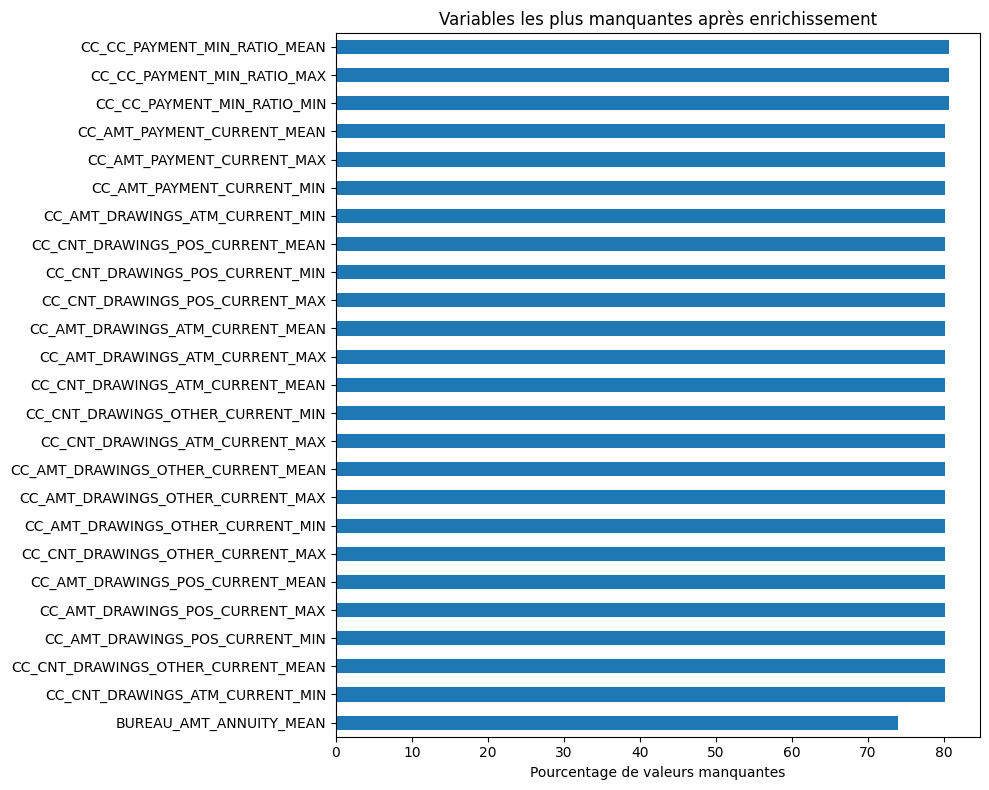

In [143]:
plt.figure(figsize=(10, 8))

final_missing_report.head(25)[
    "missing_rate_pct"
].sort_values().plot(
    kind="barh"
)

plt.title(
    "Variables les plus manquantes après enrichissement"
)

plt.xlabel("Pourcentage de valeurs manquantes")
plt.tight_layout()
plt.show()

### Identifier les colonnes numériques et catégorielles

In [145]:
feature_columns = [
    column
    for column in train_enriched.columns
    if column not in [TARGET, ID_CLIENT]
]

categorical_columns = (
    train_enriched[feature_columns]
    .select_dtypes(
        include=["object", "category", "bool"]
    )
    .columns
    .tolist()
)

numeric_columns = (
    train_enriched[feature_columns]
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

print(
    "Variables numériques :",
    len(numeric_columns)
)

print(
    "Variables catégorielles :",
    len(categorical_columns)
)

Variables numériques : 414
Variables catégorielles : 131


In [146]:
# Analyse de la cardinalité
categorical_cardinality = pd.DataFrame({
    "column": categorical_columns,
    "n_unique": [
        train_enriched[column].nunique(
            dropna=False
        )
        for column in categorical_columns
    ]
}).sort_values(
    "n_unique",
    ascending=False
)

display(categorical_cardinality)

,column,n_unique
0,CODE_GENDER_F,2
98,ORGANIZATION_TYPE_Security Ministries,2
96,ORGANIZATION_TYPE_School,2
95,ORGANIZATION_TYPE_Restaurant,2
94,ORGANIZATION_TYPE_Religion,2
...,...,...
38,OCCUPATION_TYPE_High skill tech staff,2
37,OCCUPATION_TYPE_HR staff,2
36,OCCUPATION_TYPE_Drivers,2
35,OCCUPATION_TYPE_Core staff,2


## Preprocessing

### Label Encoding and One-Hot Encoding

In [33]:
# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in application_train:
    if application_train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(application_train[col].unique())) <= 2:
            # Train on the training data
            le.fit(application_train[col])
            # Transform both training and testing data
            application_train[col] = le.transform(application_train[col])
            application_test[col] = le.transform(application_test[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [34]:
# one-hot encoding of categorical variables
application_train = pd.get_dummies(application_train)
application_test = pd.get_dummies(application_test)

print('Training Features shape: ', application_train.shape)
print('Testing Features shape: ', application_test.shape)

Training Features shape:  (307511, 244)
Testing Features shape:  (48744, 239)


### Aligning Training and Testing Data

In [35]:
train_labels = application_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
application_train, application_test = application_train.align(application_test, join = 'inner', axis = 1)

# Add the target back in
application_train['TARGET'] = train_labels

print('Training Features shape: ', application_train.shape)
print('Testing Features shape: ', application_test.shape)

Training Features shape:  (307511, 240)
Testing Features shape:  (48744, 239)


### Corriger les anomalies
#### La variable DAYS_EMPLOYED

In [36]:
anom = application_train[application_train['DAYS_EMPLOYED'] == 365243]
non_anom = application_train[application_train['DAYS_EMPLOYED'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.07% of loans
The anomalies default on nan% of loans
There are 0 anomalous days of employment


In [52]:
# Create an anomalous flag column
application_train['DAYS_EMPLOYED_ANOM'] = application_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
application_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

In [38]:
application_test['DAYS_EMPLOYED_ANOM'] = application_test["DAYS_EMPLOYED"] == 365243
application_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)

print('There are %d anomalies in the test data out of %d entries' % (application_test["DAYS_EMPLOYED_ANOM"].sum(), len(application_test)))


There are 9274 anomalies in the test data out of 48744 entries


#### Bin the Age data

In [41]:
# Find the correlation of the positive days since birth and target
application_train['DAYS_BIRTH'] = abs(application_train['DAYS_BIRTH'])
application_train['DAYS_BIRTH'].corr(application_train['TARGET'])

np.float64(-0.07823930830982488)

In [45]:
# Age information into a separate dataframe
age_data = application_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Bin the age data
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))

In [44]:
# Group by the bin and calculate averages
age_groups  = age_data.groupby('YEARS_BINNED').mean()

## Feature Engineering
Les compétitions Kaggle se gagnent grâce à l'ingénierie des caractéristiques (*feature engineering*) : les vainqueurs sont ceux qui parviennent à créer les variables les plus utiles à partir des données. (C'est largement vrai, car les modèles gagnants — du moins pour les données structurées — sont presque tous des variantes du *gradient boosting*). Cela illustre un principe clé de l'apprentissage automatique : l'ingénierie des caractéristiques offre un meilleur retour sur investissement que la conception du modèle ou le réglage des hyperparamètres. (Voici un excellent article à ce sujet). Comme aime à le dire Andrew Ng : « L'apprentissage automatique appliqué consiste essentiellement en de l'ingénierie des caractéristiques. »

Bien que le choix du modèle et des paramètres optimaux soit important, un modèle ne peut apprendre qu'à partir des données qui lui sont fournies. Il incombe au *data scientist* (éventuellement aidé par des outils automatisés) de veiller à ce que ces données soient aussi pertinentes que possible pour la tâche à accomplir.

L'ingénierie des caractéristiques désigne un processus global pouvant inclure à la fois la construction de caractéristiques (création de nouvelles variables à partir des données existantes) et la sélection de caractéristiques (choix des variables les plus importantes ou recours à d'autres méthodes de réduction de dimensionnalité). Il existe de nombreuses techniques pour créer et sélectionner ces caractéristiques.

Nous pratiquerons intensivement l'ingénierie des caractéristiques lorsque nous commencerons à utiliser d'autres sources de données ; toutefois, dans ce *notebook*, nous nous limiterons à deux méthodes simples de construction :

- Polynomial features
- Domain knowledge features

### Polynomial Features

Une méthode simple de construction de variables consiste à créer des variables polynomiales. Avec cette méthode, on génère des variables correspondant à des puissances de variables existantes ainsi qu'à des termes d'interaction entre ces dernières. Par exemple, on peut créer les variables EXT_SOURCE_1^2 et EXT_SOURCE_2^2, mais aussi des variables telles que EXT_SOURCE_1 x EXT_SOURCE_2, EXT_SOURCE_1 x EXT_SOURCE_2^2, EXT_SOURCE_1^2 x EXT_SOURCE_2^2, et ainsi de suite. Ces variables, qui résultent de la combinaison de plusieurs variables individuelles, sont appelées « termes d'interaction » car elles capturent les interactions entre les variables. En d'autres termes, alors que deux variables prises isolément peuvent ne pas avoir une forte influence sur la variable cible, leur combinaison en une seule variable d'interaction peut révéler une relation avec cette cible. Les termes d'interaction sont couramment utilisés dans les modèles statistiques pour capturer les effets combinés de plusieurs variables, mais ils sont moins fréquents en apprentissage automatique (machine learning). Néanmoins, nous pouvons en tester quelques-uns pour voir s'ils aident notre modèle à prédire si un client remboursera ou non son prêt.

Jake VanderPlas aborde les variables polynomiales dans son excellent ouvrage *Python for Data Science*, pour ceux qui souhaitent approfondir le sujet.

Dans le code ci-dessous, nous créons des variables polynomiales à partir des variables EXT_SOURCE et de la variable DAYS_BIRTH. Scikit-Learn propose une classe très utile, `PolynomialFeatures`, qui génère les polynômes et les termes d'interaction jusqu'à un degré spécifié. Nous pouvons utiliser un degré de 3 pour observer les résultats (lors de la création de variables polynomiales, il convient d'éviter un degré trop élevé, car le nombre de variables augmente de manière exponentielle avec le degré et l'on risque de rencontrer des problèmes de surapprentissage).

In [56]:
# Make a new dataframe for polynomial features
poly_features = application_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = application_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

# imputer for handling missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

poly_target = poly_features['TARGET']

poly_features = poly_features.drop(columns = ['TARGET'])

# Need to impute missing values
poly_features = imputer.fit_transform(poly_features)
poly_features_test = imputer.transform(poly_features_test)

from sklearn.preprocessing import PolynomialFeatures
                                  
# Create the polynomial object with specified degree
poly_transformer = PolynomialFeatures(degree = 3)

In [57]:
# Train the polynomial features
poly_transformer.fit(poly_features)

# Transform the features
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial Features shape: ', poly_features.shape)

Polynomial Features shape:  (307511, 35)


Cela génère un nombre considérable de nouvelles caractéristiques. Pour en obtenir les noms, nous devons utiliser la méthode `get_feature_names` des caractéristiques polynomiales.

In [59]:
feature_names = poly_transformer.get_feature_names_out(
    ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
)

feature_names[:15]

array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 DAYS_BIRTH',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 DAYS_BIRTH', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 DAYS_BIRTH', 'DAYS_BIRTH^2'], dtype=object)

Il y a 35 caractéristiques, incluant les caractéristiques individuelles élevées à des puissances allant jusqu'au degré 3 ainsi que des termes d'interaction. Nous pouvons maintenant examiner si certaines de ces nouvelles caractéristiques sont corrélées à la cible.

In [62]:
# Create a dataframe of the features 
poly_features = pd.DataFrame(
    poly_features,
    columns=poly_transformer.get_feature_names_out(
        ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
    )
)

# Add in the target
poly_features['TARGET'] = poly_target.values

# Find the correlations with the target
poly_corrs = poly_features.corr()['TARGET'].sort_values()

# Display most negative and most positive
print(poly_corrs.head(10))
print(poly_corrs.tail(5))

EXT_SOURCE_2 EXT_SOURCE_3                -0.193939
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.189605
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.181283
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.176428
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.172282
EXT_SOURCE_1 EXT_SOURCE_2                -0.166625
EXT_SOURCE_1 EXT_SOURCE_3                -0.164065
EXT_SOURCE_2                             -0.160295
EXT_SOURCE_2 DAYS_BIRTH                  -0.156873
EXT_SOURCE_1 EXT_SOURCE_2^2              -0.156867
Name: TARGET, dtype: float64
DAYS_BIRTH     -0.078239
DAYS_BIRTH^2   -0.076672
DAYS_BIRTH^3   -0.074273
TARGET          1.000000
1                    NaN
Name: TARGET, dtype: float64


Plusieurs des nouvelles variables présentent une corrélation plus forte (en valeur absolue) avec la cible que les caractéristiques d'origine. Lors de la construction de modèles d'apprentissage automatique, nous pouvons effectuer des essais avec et sans ces caractéristiques afin de déterminer si elles aident réellement le modèle à apprendre.

Nous ajouterons ces caractéristiques à une copie des données d'entraînement et de test, puis nous évaluerons les modèles en les incluant ou non. En apprentissage automatique, il arrive souvent que la seule façon de savoir si une approche fonctionnera soit de la tester !

In [66]:
# Put test features into dataframe
poly_features_test = pd.DataFrame(poly_features_test, 
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                                'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Merge polynomial features into training dataframe
poly_features['SK_ID_CURR'] = application_train['SK_ID_CURR']
app_train_poly = application_train.merge(poly_features, on = 'SK_ID_CURR', how = 'left')

# Merge polnomial features into testing dataframe
poly_features_test['SK_ID_CURR'] = application_test['SK_ID_CURR']
app_test_poly = application_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Align the dataframes
app_train_poly, app_test_poly = app_train_poly.align(app_test_poly, join = 'inner', axis = 1)

# Print out the new shapes
print('Training data with polynomial features shape: ', app_train_poly.shape)
print('Testing data with polynomial features shape:  ', app_test_poly.shape)

Training data with polynomial features shape:  (307511, 275)
Testing data with polynomial features shape:   (48744, 275)


### Domain Knowledge Features
Il n'est peut-être pas tout à fait exact de parler de « connaissances métier », car je ne suis pas un expert en crédit ; on pourrait plutôt qualifier cela de « tentatives d'application de connaissances financières limitées ». Dans cette optique, nous pouvons créer quelques variables visant à saisir les éléments qui nous semblent déterminants pour prédire si un client fera défaut sur son prêt. J'utiliserai ici cinq variables inspirées du script d'Aguiar :

- CREDIT_INCOME_PERCENT : le pourcentage du montant du crédit par rapport au revenu du client
- ANNUITY_INCOME_PERCENT : le pourcentage de l'annuité du prêt par rapport au revenu du client
- CREDIT_TERM : la durée de remboursement en mois (puisque l'annuité correspond au montant mensuel dû)
- DAYS_EMPLOYED_PERCENT : le pourcentage de jours d'emploi par rapport à l'âge du client

In [68]:
app_train_domain = application_train.copy()
app_test_domain = application_test.copy()

app_train_domain['CREDIT_INCOME_PERCENT'] = app_train_domain['AMT_CREDIT'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['ANNUITY_INCOME_PERCENT'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['CREDIT_TERM'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_CREDIT']
app_train_domain['DAYS_EMPLOYED_PERCENT'] = app_train_domain['DAYS_EMPLOYED'] / app_train_domain['DAYS_BIRTH']

In [69]:
app_test_domain['CREDIT_INCOME_PERCENT'] = app_test_domain['AMT_CREDIT'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['ANNUITY_INCOME_PERCENT'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['CREDIT_TERM'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_CREDIT']
app_test_domain['DAYS_EMPLOYED_PERCENT'] = app_test_domain['DAYS_EMPLOYED'] / app_test_domain['DAYS_BIRTH']

Visualiser les nouvelles variables¶
Il convient d'explorer visuellement ces variables issues de la connaissance du domaine au moyen d'un graphique. Pour chacune d'elles, nous réaliserons le même graphique de densité (KDE), avec une coloration basée sur la valeur de la cible (TARGET).

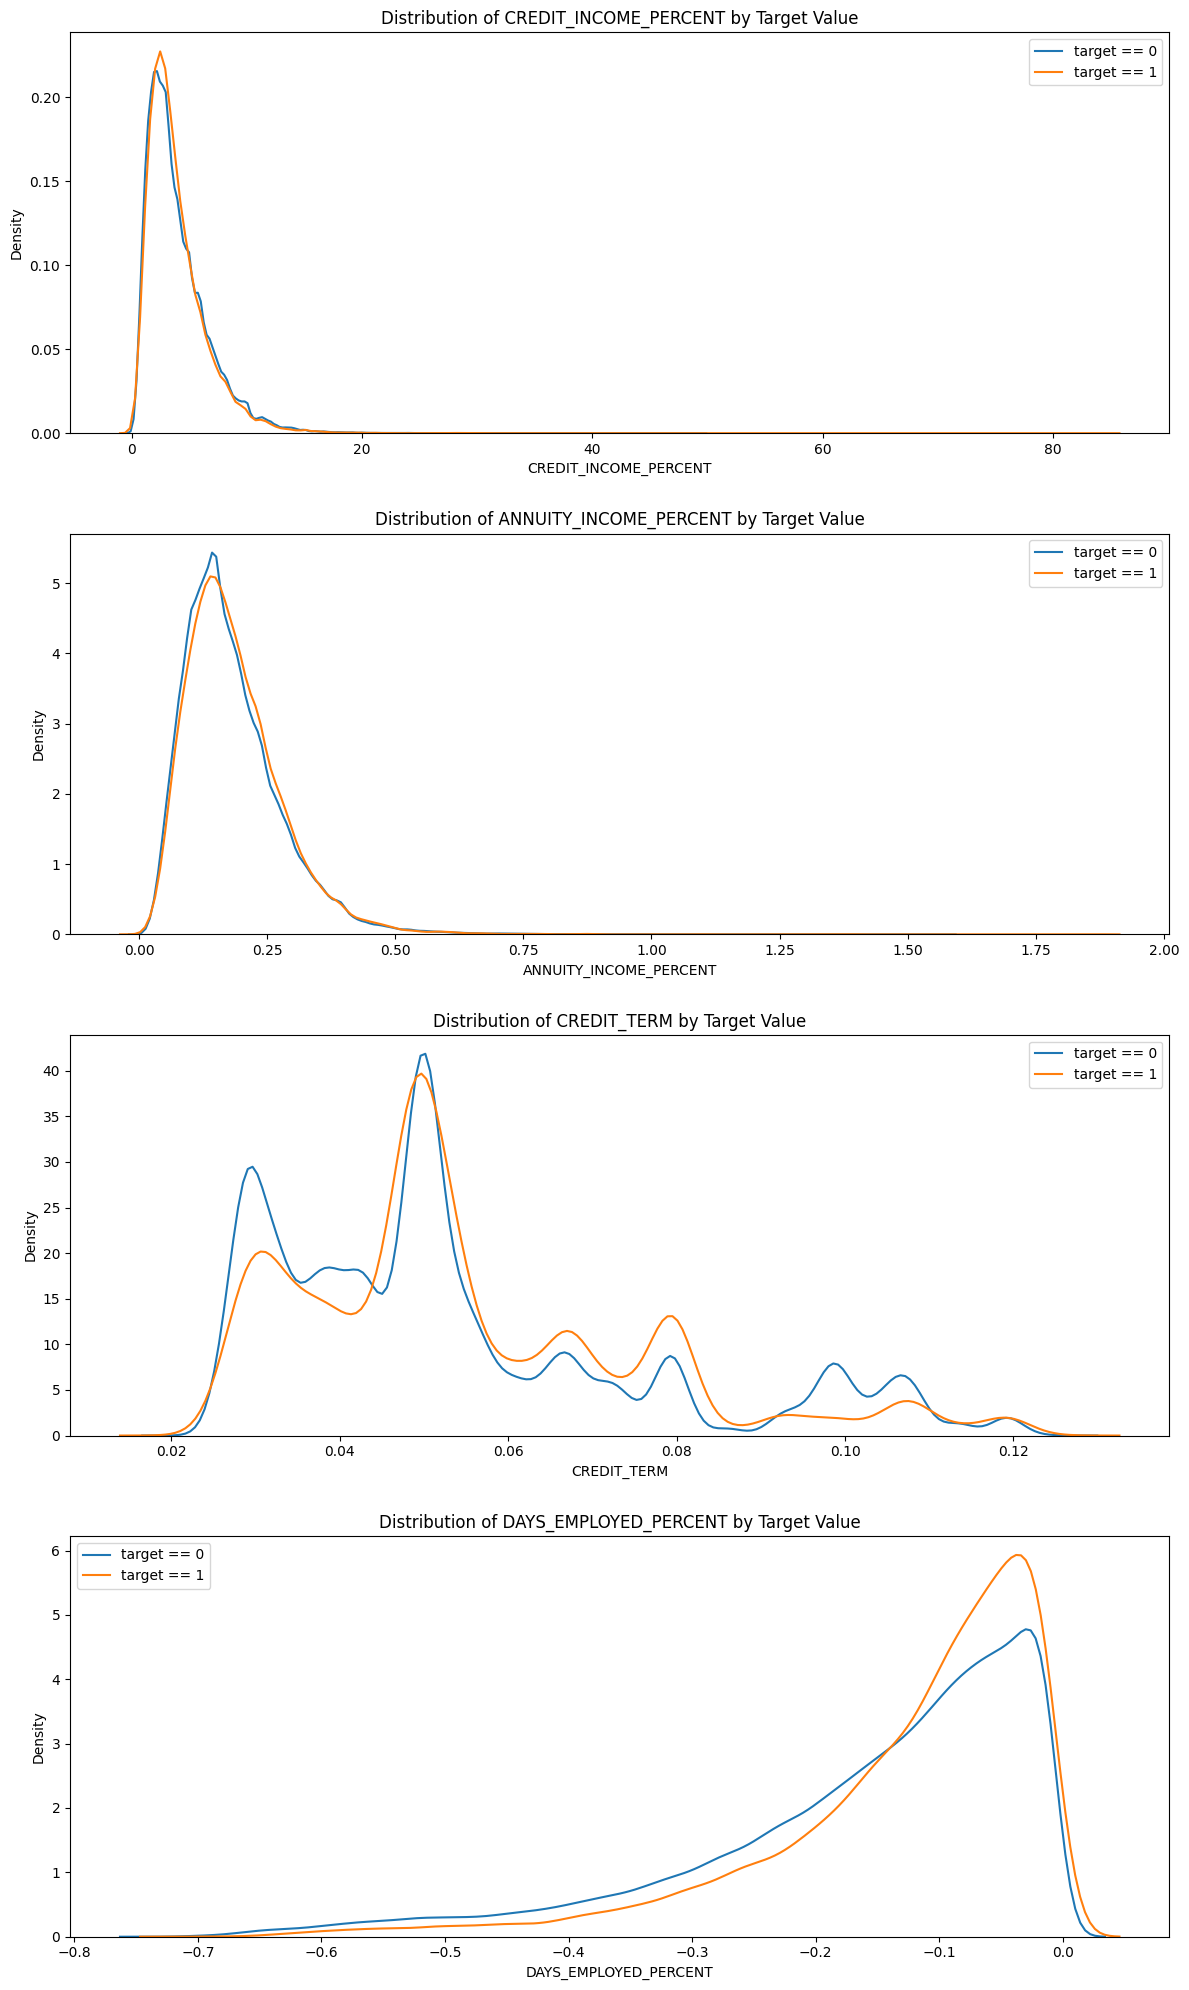

In [70]:
plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density');
    plt.legend()
    
plt.tight_layout(h_pad = 2.5)

Difficile de dire à l'avance si ces nouvelles fonctionnalités seront utiles. Le seul moyen d'en avoir le cœur net, c'est de les essayer !

## Model Training

### BaseLine
Pour un modèle de référence naïf, nous pourrions prédire la même valeur pour tous les exemples de l'ensemble de test. Comme l'objectif est de prédire la probabilité de non-remboursement du prêt, en l'absence de toute certitude, nous attribuerions une probabilité de 0,5 à toutes les observations de l'ensemble de test. Cela nous donnerait une aire sous la courbe ROC (AUC ROC) de 0,5 dans le cadre de la compétition (un choix aléatoire pour une tâche de classification donne un score de 0,5).

Connaissant déjà le score que nous obtiendrions, il n'est pas nécessaire de recourir à une telle approche naïve. Utilisons plutôt un modèle légèrement plus élaboré comme référence : la régression logistique.

### Logistic Regression
Je vais ici me concentrer sur la mise en œuvre du modèle plutôt que sur l'explication détaillée de son fonctionnement. Toutefois, pour ceux qui souhaitent approfondir la théorie des algorithmes d'apprentissage automatique, je recommande deux ouvrages : *An Introduction to Statistical Learning* et *Hands-On Machine Learning with Scikit-Learn and TensorFlow*. Ces deux livres présentent à la fois la théorie et le code nécessaire pour construire les modèles (respectivement en R et en Python). Ils reposent sur l'idée que l'apprentissage par la pratique est la méthode la plus efficace, et ils sont excellents !

Pour établir notre modèle de référence, nous utiliserons toutes les variables (ou « features ») après avoir encodé les variables catégorielles. Nous effectuerons un prétraitement des données consistant à combler les valeurs manquantes (imputation) et à normaliser l'échelle des variables (mise à l'échelle). Le code ci-dessous réalise ces deux étapes de prétraitement.

In [78]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

# Drop the target from the training data
if 'TARGET' in application_train:
    train = application_train.drop(columns = ['TARGET'])
else:
    train = application_train.copy()
    
# Feature names
features = list(train.columns)

# Copy of the testing data
test = application_test.copy()

# Median imputation of missing values
imputer = SimpleImputer(strategy='median')

# Scale each feature to 0-1
scaler = MinMaxScaler(feature_range = (0, 1))

# Fit on the training data
imputer.fit(train)

# Transform both training and testing data
train = imputer.transform(train)
test = imputer.transform(application_test)

# Repeat with the scaler
scaler.fit(train)
train = scaler.transform(train)
test = scaler.transform(test)

print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)

Training data shape:  (307511, 240)
Testing data shape:  (48744, 240)


Nous utiliserons `LogisticRegression` de Scikit-Learn pour notre premier modèle. La seule modification apportée aux paramètres par défaut consistera à réduire le paramètre de régularisation `C`, qui contrôle le niveau de surapprentissage (une valeur plus faible devrait le limiter). Cela nous permettra d'obtenir des résultats légèrement meilleurs qu'avec le modèle `LogisticRegression` standard, tout en établissant une référence modeste pour les modèles ultérieurs.

Nous utilisons ici la syntaxe de modélisation habituelle de Scikit-Learn : nous créons d'abord le modèle, nous l'entraînons à l'aide de la méthode `.fit`, puis nous effectuons des prédictions sur les données de test avec `.predict_proba` (rappelons que nous souhaitons obtenir des probabilités plutôt qu'une valeur binaire 0 ou 1).

In [79]:
from sklearn.linear_model import LogisticRegression

# Make the model with the specified regularization parameter
log_reg = LogisticRegression(C = 0.0001)

# Train on the training data
log_reg.fit(train, train_labels)

LogisticRegression(C=0.0001)

Maintenant que le modèle a été entraîné, nous pouvons l'utiliser pour effectuer des prédictions. Nous souhaitons prédire les probabilités de non-remboursement d'un prêt ; nous utilisons donc la méthode `predict_proba` du modèle. Celle-ci renvoie un tableau de dimensions *m* x 2, où *m* représente le nombre d'observations. La première colonne correspond à la probabilité que la cible soit égale à 0, et la seconde à la probabilité qu'elle soit égale à 1 (ainsi, pour une ligne donnée, la somme des deux colonnes doit être égale à 1). Comme nous voulons connaître la probabilité de non-remboursement du prêt, nous sélectionnons la seconde colonne.

Le code suivant effectue les prédictions et sélectionne la colonne appropriée.

In [80]:
# Make predictions
# Make sure to select the second column only
log_reg_pred = log_reg.predict_proba(test)[:, 1]

Les prédictions doivent respecter le format du fichier `sample_submission.csv`, qui ne comporte que deux colonnes : `SK_ID_CURR` et `TARGET`. Nous créerons un DataFrame nommé `submit` dans ce format, à partir de l'ensemble de test et des prédictions.

In [83]:
# Submission dataframe
submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = log_reg_pred

submit.head()

,SK_ID_CURR,TARGET
0,100001,0.078497
1,100005,0.137631
2,100013,0.082206
3,100028,0.080830
4,100038,0.132673


Les prédictions représentent une probabilité comprise entre 0 et 1 que le prêt ne soit pas remboursé. Si nous utilisions ces prédictions pour classer les demandeurs, nous pourrions fixer un seuil de probabilité pour déterminer si un prêt est risqué.

In [84]:
# Save the submission to a csv file
submit.to_csv('log_reg_baseline.csv', index = False)

### Improved Model: Random Forest
Pour tenter de surpasser les piètres performances de notre modèle de référence, nous pouvons changer d'algorithme. Essayons d'utiliser une forêt aléatoire sur les mêmes données d'entraînement afin d'observer l'impact sur les performances. La forêt aléatoire est un modèle bien plus puissant, surtout lorsque l'on utilise des centaines d'arbres. Nous utiliserons 100 arbres pour cette forêt aléatoire.

In [85]:
from sklearn.ensemble import RandomForestClassifier

# Make the random forest classifier
random_forest = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

In [86]:
# Train on the training data
random_forest.fit(train, train_labels)

# Extract feature importances
feature_importance_values = random_forest.feature_importances_
feature_importances = pd.DataFrame({'feature': features, 'importance': feature_importance_values})

# Make predictions on the test data
predictions = random_forest.predict_proba(test)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   13.7s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.1s finished


In [87]:
# Make a submission dataframe
submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = predictions

# Save the submission dataframe
submit.to_csv('random_forest_baseline.csv', index = False)

Ces prédictions seront également disponibles lorsque nous exécuterons le notebook dans son intégralité.

Ce modèle devrait obtenir un score d'environ 0,678 lors de la soumission.